
# Trabalho #2 - Classificação binária com rede neural deep-learning

Nesse trabalho você vai desenvolver uma rede neural rasa e uma deep-learning, usando a plataforma TensorFlow-Keras, para realizar uma tarefa de classificação binária para reconhecer gatos em imagens e comparar o desempenho das duas redes.

## Coloque os nomes e RAs dos alunos que fizeram esse trabalho

Nome e número dos alunos da equipe:

Aluno 1:



## 1 - Bibliotecas ##

Em primeiro ligar, execute a célula abaixo para importar algumas bibliotecas Python que são usadas nesse trabalho.

O comando da célula abaixo importa o TensorFlow e verifica a versão que está sendo utilizada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
import tensorflow as tf
tf.__version__

'2.19.0'

## 2 - Visão geral do problema ##

**Definição do problema**:

Nesse trabalho é fornecido um conjunto de dados que contém:

    - um conjunto de imagens de treinamento classificadas como tendo gato (y=1) ou não tendo gato (y=0);
    - um conjunto de imagens de teste classificadas como tendo gato (y=1) ou não tendo gato (y=0);
    - a dimensão de cada imagem é (num_px, num_px, 3), onde 3 é o número de canais de cor (RGB);
    - cada imagem é composta por três matrizes de dimensão: número de linhas = num_px e número de colunas = num_px;
    - número de imagens do conjunto de treinamento: m_train;
    - número de imagens do conjunto de teste: m_test.

A partir desses conjuntos de dados, a sua tarefa é desenvolver um sistema baseado em uma rede neural, para processar imagens e classificar corretamente se ela mostra ou não um gato. Para isso, você vai desenvolver duas redes neurais usando a ferramenta Keras e comparar o desempenho delas.

O uso da ferramenta Keras para desenvolver redes neurais facilita muito o trabalho, pois não exige desenvolver codigos específicos para implementar cada camada da rede, a função de custo, a métrica e principalmente o gradiente descendente.

## 3 - Conjunto de dados de treinamento e teste

O conjunto de dados utilizado pode ser obtido em: https://www.kaggle.com/datasets/tongpython/cat-and-dog. Para carregar esse conjunto de dados execute os códigos das células a seguir.


In [2]:
# Carrega arquivo de dados compactado
import gdown
url = "https://drive.google.com/uc?id=1QiTwI37iSHf1_xyO3lXX2gnvJh7wEPhq"
output = "cats_dogs_4000.zip"
gdown.download(url, output)

Downloading...
From (original): https://drive.google.com/uc?id=1QiTwI37iSHf1_xyO3lXX2gnvJh7wEPhq
From (redirected): https://drive.google.com/uc?id=1QiTwI37iSHf1_xyO3lXX2gnvJh7wEPhq&confirm=t&uuid=781c8e88-abb6-485a-93f6-a5b165fc20ea
To: /content/cats_dogs_4000.zip
100%|██████████| 228M/228M [00:01<00:00, 130MB/s]


'cats_dogs_4000.zip'

In [3]:
# Descompacta arquivo de dados
!unzip -d /content/cats_dogs -q /content/cats_dogs_4000.zip

In [4]:
# Define diretórios onde se encontram as imagens
cat_train_dir = '/content/cats_dogs/training_set/training_set/cats'
dog_train_dir = '/content/cats_dogs/training_set/training_set/dogs'
cat_test_dir = '/content/cats_dogs/test_set/test_set/cats'
dog_test_dir = '/content/cats_dogs/test_set/test_set/dogs'

In [5]:
# Escolhe tipo de arquivos desejados
glob_imgs_cat_train = os.path.join(cat_train_dir, '*.jpg')
glob_imgs_cat_test = os.path.join(cat_test_dir, '*.jpg')
glob_imgs_dog_train = os.path.join(dog_train_dir, '*.jpg')
glob_imgs_dog_test = os.path.join(dog_test_dir, '*.jpg')

# Cria lista dos nomes dos arquivos
train_cat_img_paths = glob(glob_imgs_cat_train)
test_cat_img_paths = glob(glob_imgs_cat_test)
train_dog_img_paths = glob(glob_imgs_dog_train)
test_dog_img_paths = glob(glob_imgs_dog_test)

# Imprime nomes e paths dos 5 primeiros arquivos das listas
print('Numero de imagens de treinamento:', len(train_cat_img_paths))
print('Numero de imagens de treinamento:', len(train_dog_img_paths))
print('Numero de imagens de validação:', len(test_dog_img_paths))
print('Numero de imagens de validação:', len(test_dog_img_paths),'\n')
print(train_cat_img_paths[:5])
print(' ')
print(test_cat_img_paths[:5])

Numero de imagens de treinamento: 4000
Numero de imagens de treinamento: 4005
Numero de imagens de validação: 1012
Numero de imagens de validação: 1012 

['/content/cats_dogs/training_set/training_set/cats/cat.2855.jpg', '/content/cats_dogs/training_set/training_set/cats/cat.1381.jpg', '/content/cats_dogs/training_set/training_set/cats/cat.1046.jpg', '/content/cats_dogs/training_set/training_set/cats/cat.2189.jpg', '/content/cats_dogs/training_set/training_set/cats/cat.780.jpg']
 
['/content/cats_dogs/test_set/test_set/cats/cat.4049.jpg', '/content/cats_dogs/test_set/test_set/cats/cat.4117.jpg', '/content/cats_dogs/test_set/test_set/cats/cat.4230.jpg', '/content/cats_dogs/test_set/test_set/cats/cat.4199.jpg', '/content/cats_dogs/test_set/test_set/cats/cat.4076.jpg']


In [6]:
# Lê arquivos das imagens e cria lista de imagens e de classes com dimensão 64x64 e normalizadas entre 0 e 1
y_train, y_test = [], []
x_train, x_test = [], []

for file in train_cat_img_paths:
  y_train.append(1)
  image = tf.keras.utils.load_img(file)
  img = tf.keras.utils.img_to_array(image)
  imgr = tf.image.resize(image, [64,64])
  x_train.append(np.array(imgr))

for file in train_dog_img_paths:
  y_train.append(0)
  image = tf.keras.utils.load_img(file)
  img = tf.keras.utils.img_to_array(image)
  imgr = tf.image.resize(image, [64,64])
  x_train.append(np.array(imgr))

for file in test_cat_img_paths:
  y_test.append(1)
  image = tf.keras.utils.load_img(file)
  img = tf.keras.utils.img_to_array(image)
  imgr = tf.image.resize(image, [64,64])
  x_test.append(np.array(imgr))

for file in test_dog_img_paths:
  y_test.append(0)
  image = tf.keras.utils.load_img(file)
  img = tf.keras.utils.img_to_array(image)
  imgr = tf.image.resize(image, [64,64])
  x_test.append(np.array(imgr))

In [7]:
# Transforma lista em tensores numpy
x_train = np.stack(x_train)
y_train = np.stack(y_train)
x_test = np.stack(x_test)
y_test = np.stack(y_test)

**Embaralhamento aleatório dos dados**

É muito importante embaralhar os dados antes de usá-los para treinar uma RNA. Na célula abaixo é realizado esse embaralhamento usando a função "shuffle" da biblioteca ScikitLearn.

Note que o embaralhamento tem que ser realizado conjuntamente para os dados de entrada e de saída.

In [8]:
# Embaralhamrento dos dados
from sklearn.utils import shuffle
x_train, y_train = shuffle(x_train, y_train, random_state=21)
x_test, y_test = shuffle(x_test, y_test, random_state=21)

print('Dimensões dos dados de treinamento:', x_train.shape, y_train.shape)
print('Dimensões dos dados de teste', x_test.shape, y_test.shape)

Dimensões dos dados de treinamento: (8005, 64, 64, 3) (8005,)
Dimensões dos dados de teste (2023, 64, 64, 3) (2023,)


(64, 64, 3)
y = 0


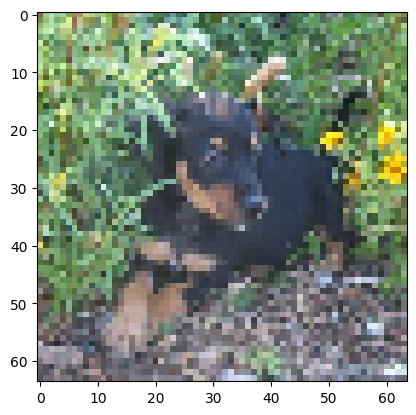

In [9]:
# Examplo de uma imagem
index = 10
print(x_train[index].shape)
plt.imshow(x_train[index]/255.)
print ("y = " + str(y_train[index]))

### 3.1 - Determinação do formato e dimensões dos dados

### Exercício #1:

É importante conhecer as dimensões dos dados que estamos trabalhando para evitar problemas. Assim, obtenha os valores dos seguintes parâmetros:

    - m_train = número de exemplos de treinamento;
    - m_test = número de exemplos de teste;
    - num_px = altura e largura das imagens (as imagens são quadradas).
    
Lembre que `x_train` é um tensor numpy de dimensão (m_train, num_px, num_px, 3). Por exemplo, você pode obter  `m_train` escrevendo `x_train.shape[0]`.

In [10]:
# PARA VOCÊ FAZER:

### COMECE AQUIE ### (≈ 3 linhas)
m_train = x_train.shape[0]
m_test = x_test.shape[0]
num_px = x_train.shape[1]
### TERMINE AQUI ###

print ("Número de exemplos de treinamento: m_train = " + str(m_train))
print ("Número de exemplos de teste: m_test = " + str(m_test))
print ("Altura/largura de cada imagem: num_px = " + str(num_px))
print ("Dimensão de cada imagem: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("Dimensão - x_train: " + str(x_train.shape))
print ("Dimensão - y_train: " + str(y_train.shape))
print ("Dimensão - x_test: " + str(x_test.shape))
print ("Dimensão - y_test: " + str(y_test.shape))

Número de exemplos de treinamento: m_train = 8005
Número de exemplos de teste: m_test = 2023
Altura/largura de cada imagem: num_px = 64
Dimensão de cada imagem: (64, 64, 3)
Dimensão - x_train: (8005, 64, 64, 3)
Dimensão - y_train: (8005,)
Dimensão - x_test: (2023, 64, 64, 3)
Dimensão - y_test: (2023,)


**Saída esperada para m_train, m_test e num_px**:

    Número de exemplos de treinamento: m_train = 8005
    Número de exemplos de teste: m_test = 2023
    Altura/largura de cada imagem: num_px = 64
    Dimensão de cada imagem: (64, 64, 3)
    Dimensão - x_train: (8005, 64, 64, 3)
    Dimensão - y_train: (8005,)
    Dimensão - x_test: (2023, 64, 64, 3)
    Dimensão - y_test: (2023,)

Observe que o primeiro eixo dos tensores com as imagens dos conjuntos de teste e de treinamento representa os exemplos, da forma como é esperado para os dados no Keras.

### 3.2 - Processamento dos dados

Os dados dos exemplos de treinamento e de teste devem ser processados de forma a serem colocados em tensores com as dimensões adequadas e normalizados corretamente. Nos exercícios que seguem você irá realizar o processamento dos dados de forma a poderem ser usados na sua RNA implementada com o Keras.

### Redimensionamento dos dados

Os dados de entrada de uma camada de neurônios densa é um vetor, assim, devemos redimensionar as imagens, que tem dimensão (num_px, num_px, 3), para transformá-las em um vetor linha de dimensão (1, num_px∗num_px∗3). Após esse redimensionamento o conjunto de dados é um tensor numpy onde cada linha representa uma imagem "esticada". O tensor com as entradas dos dados de treinamento terá m_train linhas e o de teste m_test linhas.

Por exemplo, para redimensionar uma matriz de dimensão (a,b,c,d) para uma matriz de dimensão (a, b∗c∗d) pode-se usar o seguinte código Python:

    X_flatten = X.reshape((a, b∗c∗d))

A dimensão dos dados de saída também deve ser alterada porque, como visto, o Keras espara que os exemplos representam o primeiro eixo do tensor e nos dados de saída os exemplos representam o segundo eixo. Assim, os vetores com os dados de saída, tanto de treinamento como de teste, devem ser transpostos.

### Exercício #2:

Implemente o redimensionamento dos dados de entrada na célula a seguir.

In [14]:
# PARA VOCÊ FAZER: redimensionamento das imagens dos exemplos de treinamento e teste

### COMECE AQUI ### (≈ 2 linhas)
x_train_flatten = x_train.reshape(x_train.shape[0], 64*64*3)
x_test_flatten = x_test.reshape(x_test.shape[0], 64*64*3)
### TERMINE AQUI ###

print ("Dimensão - x_train_flatten: " + str(x_train_flatten.shape))
print ("Dimensão - y_test_flatten: " + str(x_test_flatten.shape))
print ("Verificação de valores após redimensionamento: " + str(x_train_flatten[0,0:5]))

Dimensão - x_train_flatten: (8005, 12288)
Dimensão - y_test_flatten: (2023, 12288)
Verificação de valores após redimensionamento: [113.276245 123.47937  128.28406   72.207275  71.05945 ]


**Saída esperada**:

    Dimensão - x_train_flatten: (8005, 12288)
    Dimensão - y_test_flatten: (2023, 12288)
    Verificação de valores após redimensionamento: [246.94434 245.94434 241.94434 244.875   243.875  ]

### Normalização dos dados

Nas imagens coloridas as cores vermelho, verde e azul (RGB) são especificadas para cada pixel da imagem, de forma que cada pixel consite de um vetor de tres números que variam no intervalo de 0 a 255.

Uma etapa do processamento dos dados é normalizar esses dados de forma a ter dados com média zero e desvio padrão um. No caso de imagens o processo de normalização dos dados é mais simples e consiste simplesmente em dividir todos os valores da imagem por 255, que é o valor máximo de um pixel.

### Exercício #3:

Implemente a normalização dos dados de forma a ter todas os elementos dos dados de entrada entre 0 e 1.

In [15]:
# PARA VOCÊ FAZER: redimensionamento das imagens dos exemplos de treinamento e teste

### COMECE AQUI ### (≈ 2 linhas)
x_train_norm = x_train_flatten / 255.
x_test_norm = x_test_flatten / 255.
### TERMINE AQUI ###

print ("Máximo e mínimo valores de x_train_norm:", np.max(x_train_norm),'/', np.min(x_train_norm))
print ("Máximo e mínimo valores valor de train_set_x:", np.max(x_test_norm),'/', np.min(x_test_norm))

Máximo e mínimo valores de x_train_norm: 1.0 / 0.0
Máximo e mínimo valores valor de train_set_x: 1.0 / 0.0


**Saída esperada**:

    Máximo e mínimo valores de x_train_norm: 1.0 / 0.0
    Máximo e mínimo valores valor de train_set_x: 1.0 / 0.



<font color='blue'>
    
**O que é importante lembrar:**

As etapas principais do processamento de dados são as seguintes:
- Verificar a dimensão e formato dos dados do problema. Nesse caso são: m_train, m_test, num_px, ...
- Redimensionar os conjuntos de dados. Nesse caso para cada exemplo a entrada é um vetor linha de dimensão (1, num_px \* num_px \* 3)
- Normalizar os dados

## 4 - Desenvolvimento e teste da rede neural rasa

Nesse trabalho vamos testar diferentes redes neurais, variando numero de camadas, numero de neurônios nas camadas e tipo de função de ativação para obtermos uma solução que apresente resultados satisfatórios.

Conforme vimos em aula, o desenvolvimento de uma RNA com o Keras é feito segundo as seguintes etapas:

1. Definição dos dados de treinamento e de teste;
2. Configuração da RNA;
3. Compilação da RNA, que também inclui a configuração do processo de treinamento pela escolha da função de custo, do otimizador e da métrica para avaliar o desempenho;
4. Treinamento da RNA;
5. Teste e avaliação do desempenho da RNA.

Observe que a etapa de definição e preparação dos dados já foi realizada.

### 4.1 - Configuração da rede neural ##

Vamos configurar, treinar e testar uma primeira rede neural simples de uma camada intermediária usando o Keras.

Para essa rede de uma camada, o parâmetro mais importante é o número de neurônios da camada intermediária. Esse número deve ser compatível com o problema que queremos resolver e também com o número de exemplos que temos disponíveis para treinar a rede.

Em linhas gerais cada imagem é representada por 12.288 números e temos 8005 imagens de treinamento. Assim, no conjunto de dados de treinamento temos cerca de 98,3 milhões de valores. Existem um princípio em aprendizado supervisionado que diz que o número de parâmetros do sistema deve ser menor do que o número de valores presente no conjunto de dados utilizado para o treinamento. Assim, a sua rede neural deve ter um número de parâmetros menor do que 98,3 milhões. Se a rede possuir número da mesma ordem de grandeza do  número de valores presentes no conjunto de dados, ela simplesmente memoriza os dados de treinamento e não funciona direito para nenhum outro caso. Veremos com detalhes esse tipo de problema, mas é importante você estar ciente disso nesse momento.

**Qualquer dúvida que você possa ter de como fazer esse trabalho usando o Keras, ela pode ser sanada olhando as notas da Aula 7 - Ferramentas de Desenvolvmento.**

### Exercício #4:

Usando o Keras configure uma rede neural com as seguintes caracteríticas:

- uma única camada intermediária com 64 neurônios e função de ativação sigmóide;
- como queremos resolver um problema de classificação binária a camada de saída deve possuir um único neurônio e ter função de ativação sigmóide.


In [16]:
# PARA VOCÊ FAZER: configuração de uma RNA rasa

# Importar do Keras classes de modelos e camadas
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

np.random.seed(1) # inicializa gerador de números aleatórios

# Configuração da rede
### COMECE AQUI ### (≈ 3 linhas)
rna = Sequential()
rna.add(Dense(units=64, activation='sigmoid', input_dim = 12288))
rna.add(Dense(units=1, activation='sigmoid'))


### TERMINE AQUI ###

# Visualização da rede
rna.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       786,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 786,561 (3.00 MB)

 Trainable params: 786,561 (3.00 MB)

 Non-trainable params: 0 (0.00 B)

**Saída esperada:**

    Model: "sequential"
    _________________________________________________________________
    Layer (type)                 Output Shape              Param #   
    =================================================================
    dense (Dense)                (None, 64)                786496    
    _________________________________________________________________
    dense_1 (Dense)              (None, 1)                 65        
    =================================================================
    Total params: 786,561
    Trainable params: 786,561
    Non-trainable params: 0
    _________________________________________________________________

### 4.2 - Compilação e treinamento da rede neural

A segunda e terceira etapas de desenvolvimento da rede no Keras é a sua compilação e treinamento.

### Exercício #5:

Compile e treine a sua rede neural usando as seguintes opções:

- Método de otimização: gradiente descendente;
- Função de custo: entropia cruzada;
- Métrica: exatidão;
- No treinamento, utilize no método fit o parâmetro batch_size=128;
- Número de épocas: 10.

Nesse momento estamos treinando a rede somente para verificar se ela é adequada para resolver o problema e se está configurada de forma correta, por isso usamos poucas épocas de treinamento.

In [21]:
# PARA VOCÊ FAZER: configuração do otimizador e treinamento da RNA rasa

# Importar do Keras classe de otimizadores
from tensorflow.keras import optimizers

# Compilação da rede
### COMECE AQUI ### (≈ 1 ou 2 linhas)
sgd = optimizers.SGD(learning_rate=0.5)
rna.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer=sgd)
### TERMINE AQUI ###

# Teste de treinamento da rede
### COMECE AQUI ### (≈ 1 linha)
historia = rna.fit(x_train_norm, y_train, epochs=10, verbose=1, batch_size=128)
### TERMINE AQUI ###

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5949 - loss: 0.6707
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6085 - loss: 0.6724
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6140 - loss: 0.6501
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6289 - loss: 0.6506
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6298 - loss: 0.6504
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6207 - loss: 0.6473
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6375 - loss: 0.6377
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6360 - loss: 0.6330
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6361 - loss: 0.6382
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6530 - loss: 0.6213


**Saída esperada:**

    Epoch 1/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5004 - loss: 0.7107
    Epoch 2/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5351 - loss: 0.6905
    Epoch 3/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5576 - loss: 0.6863
    Epoch 4/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5598 - loss: 0.6820
    Epoch 5/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5641 - loss: 0.6790
    Epoch 6/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5713 - loss: 0.6780
    Epoch 7/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5795 - loss: 0.6748
    Epoch 8/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5846 - loss: 0.6717
    Epoch 9/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5855 - loss: 0.6716
    Epoch 10/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5920 - loss: 0.6693
    
Se o seu resultado é esse ou parecido com esse, você pode conluir que a rede está correta e é capaz de aprender os dados de treinamento. Assim, agora você está pronto para treinar a rede de verdade.

### Exercício #6:

Retreine a sua rede usando 1000 épocas.

Use a opção de **não imprimir** os resultados parciais do treinamento para não gerar tantos dados. No Keras podemos escolher como monitoramos o progresso do treinamento com o parâmetro verbose do método fit, que nos dá as seguintes opções:

- verbose: inteiro = 0, 1, or 2.
- verbose = 0: silencioso;
- verbose = 1; barra de progresso (padrão);
- verbose = 2; uma linha por época.

Guarde os resultados do treinamento para poder fazer um gráfico do processo de treinamento. Se tiver dúvidas, veja nas notas da Aula 7 como fazer isso.

Não se esqueça de usar no método fit o parâmetro batch_size=128.

Esse treinamento pode levar alguns minutos.

In [22]:
# PARA VOCÊ FAZER: treinamento da RNA por 1000 épocas

### COMECE AQUI ### (≈ 1 linha)
history = rna.fit(x_train_norm, y_train, epochs=1000, verbose=0, batch_size=128)
### TERMINE AQUI ###

In [23]:
# Vamos verificar quais variáveis foram salvas no processo de treinamento
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss'])

### 4.3 - Visualização do resultado do treinamento

Para sabermos como o treinamento foi realizado precisamos visualizar a função de custo e a métrica ao longo do processo de treinamento.

### Exercício #7:

Implemente na célula abaixo a visualização dos resultados do treinamento. Observe que os valores da função de custo e da métrico estão no dicionário history com nomes `'loss'` e `'acc'`.

Consulte as notas da Aula 7 para relembrar como fazer os gráficos da função de custo e da métrica em função do número de épocas.

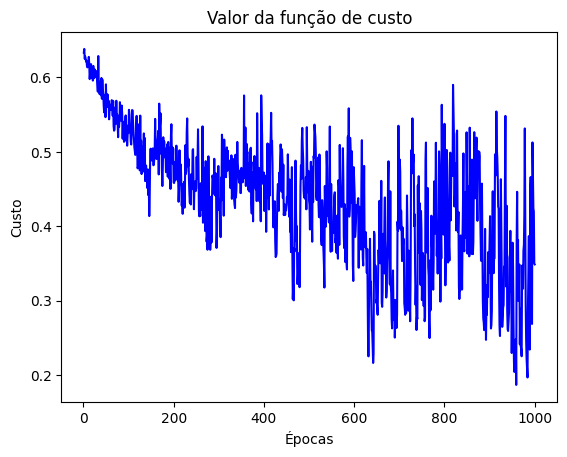

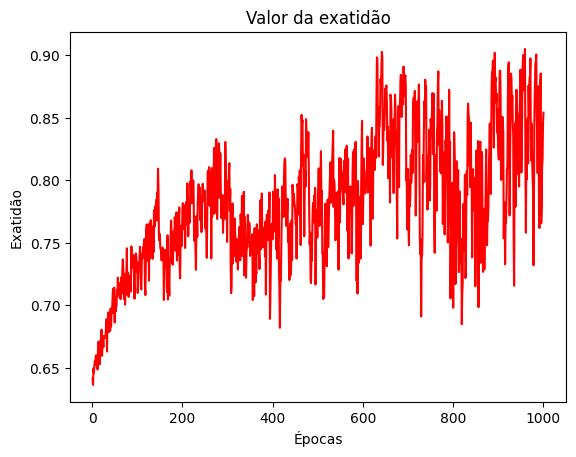

In [24]:
# PARA VOCÊ FAZER: visualização do resultado do treinamento

# Salva custo e exatidão em vetores
### COMECE AQUI ### (≈ 2 linhas)
custo = history.history['loss']
exatidao = history.history['accuracy']
### TERMINE AQUI ###

# Cria vetor de épocas
### COMECE AQUI ### (≈ 1 linha)
epocas = range(1, len(custo) + 1)
### TERMINE AQUI ###

# Gráfico do custo em funçaõ das épocas
### COMECE AQUI ### (≈ 5 linhas)
plt.plot(epocas, custo, 'b')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.show()
### TERMINE AQUI ###

# Gráfico da exatidão em função das épocas
### COMECE AQUI ### (≈ 5 linhas)
plt.plot(epocas, exatidao, 'r')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.show()
### TERMINE AQUI ###

**Saída esperada:**

O comportamento esperado para a função de custo durante o treinamento é ela decrescer monotomicamente do início até o final. Para a exatidão, o comportamento esperado é ela aumentar durante o treinamento, apresentando algumas oscilações e alcançando um valor alto no final.

Se você obteve esses resultados, então, a sua rede foi treinada de forma satisfatória e pode-se concluir que ela tem uma capacidade alta para se ajustar aos dados de treinamento.

### 4.4 - Avaliação do desempenho da rede neural ###

Após treinar a RNA é importante avaliar o seu desempenho com dados que não foram  utilizados no treinamento. Para isso usamos o dados de teste, que estão nos tensores x_test_norm e y_test.

### Exercício #8:

Avalie a sua rede neural calculando os valores da função de custo e da exatidão para os dados de teste usando o método evaluate, conforme visto na Aula 7 - Ferramentas de desenvolvimento. Calcule esses valores também para os dados de treinamento para poder fazer comparação.

In [25]:
# PARA VOCÊ FAZER: calculo do custo e exatidão para os dados de teste

# Usando método evaluate calcule o custo e a exatidão para os dados de treinamento e depois apresente os resultados
### COMECE AQUI ### (≈ 2 linhas)
custo_e_metricas_train = rna.evaluate(x_train_norm, y_train)
print("Treino: ", custo_e_metricas_train)
### TERMINE AQUI ###

# Usando método evaluate calcule o custo e a exatidão para os dados de teste e depois apresente os resultados
### COMECE AQUI ### (≈ 2 linhas)
custo_e_metricas_test = rna.evaluate(x_test_norm, y_test)
print("Teste:", custo_e_metricas_test)
### TERMINE AQUI ###

251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8148 - loss: 0.3669
Treino:  [0.37550604343414307, 0.8104934692382812]
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6228 - loss: 1.1439
Teste: [1.1592321395874023, 0.6040533781051636]


**Resultados esperados:**

    251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9840 - loss: 0.1169
    [0.09105655550956726, 0.9902560710906982]
    64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6199 - loss: 0.9448
    [0.9257866740226746, 0.6342066526412964]

**Comentários:**

- A exatidação obtida com os dados de treinamento é cerca de 99%, isso significa que a sua rede é satisfatória para resolver esse problema.

- A exatidão obtida com os dados de teste é de cerca de 63%. Esse resultado de fato não é muito bom para essa tarefa simples de classificação.

Analisando esses dados surge uma dúvida. Porque a rede não foi capaz de apresentar um bom desempenho nos dados de teste, se os resultados foram bons nos dados de treinamento?

### Exercício #9:

Para avaliar melhor o desepenho da sua rede calcule as saídas previstas dos exemplos do conjunto de teste usando o método predict e a função numpy round faça um gráfico com as classes reais e previstas dos dados do conjunto de teste. Se não souber como fazer consulte a Aula 7 - Ferramentas de desenvolvimento.

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


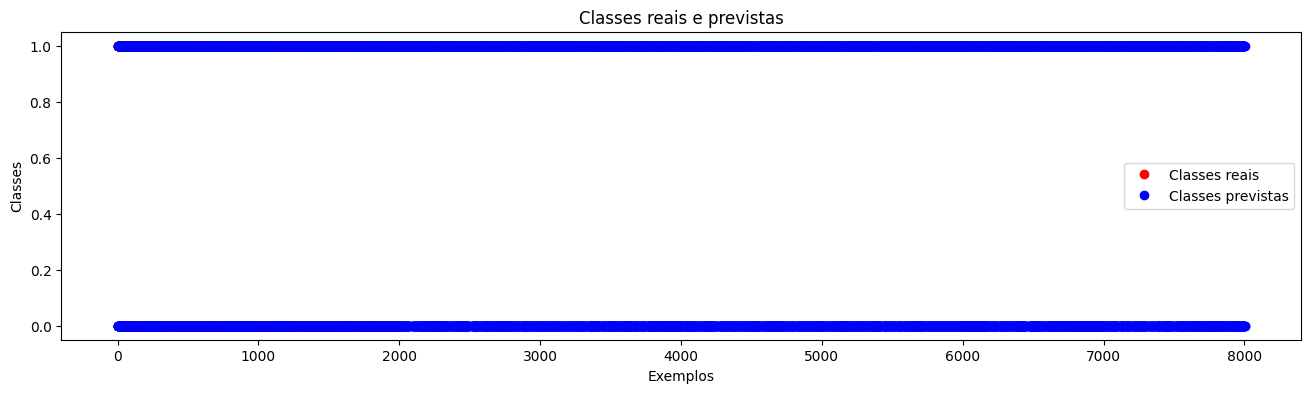

In [28]:
# PARA VOCÊ FAZER: calculo das classes previstas dos dados de teste

# Usando método predict calcule as classes previstas
### COMECE AQUI ### (≈ 3 linhas)
y_prev = rna.predict(x_test_norm)
yy_prev = rna.predict(x_train_norm)
# Transforma saida prevista em números inteiros
yy_prev = np.round(yy_prev)

### TERMINE AQUI ###

# Gráfico das classes reais e previstas
### COMECE AQUI ### (≈ 7 linhas)
plt.figure(figsize=(16,4))
plt.plot(y_test, 'ro', label='Classes reais')
plt.plot(yy_prev, 'bo', label='Classes previstas')
plt.title('Classes reais e previstas')
plt.xlabel('Exemplos')
plt.ylabel('Classes')
plt.legend()
plt.show()
### TERMINE AQUI ###

**Saída esperada**

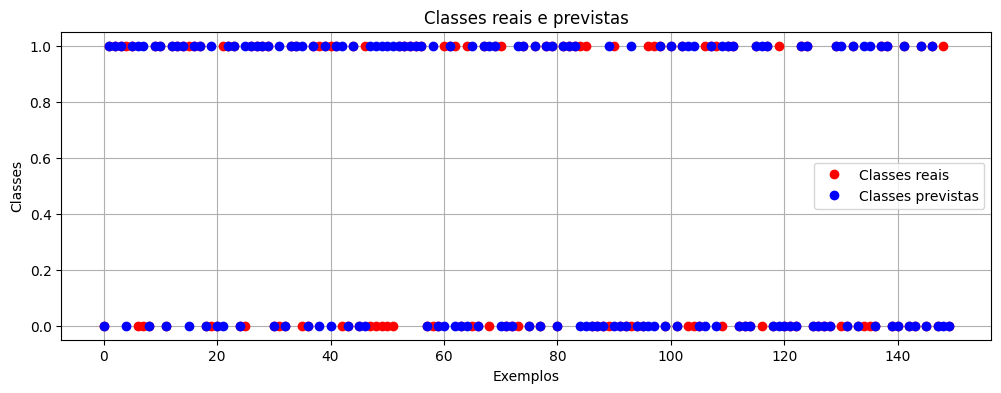

**Importante:**

Para mostrar uma imagem em uma célula de texto (markdown) no **Google Colab** deve-se usar o seguinte procedimento:

1. Na célula de texto clicar em inserir imagem. Ao fazer isso é aberta um ateal apar você escolher o arquivo da imagem. Navege no seu computador até achar a imagem e selecione a mesma.
2. A imagem é carregada no Colab codificada em Base64, que consiste de uma longa lista de strings. Cada stirng dessa lista representa um pixel da imagem.


**Comentários:**

- Uma previsão errada de classe pode ser dectada pelos círculos vermelhos, pois quando a classe prevista é igual à classe real o círculo azul é colocado em cima do vermelho tapando-o.

- Provavelmente no grafico devem aparecer mais círculos azuis do que vermelhos indicando que existem mais acertos do que erros na previsão das classes.

Use o código a seguir, mudando a variável 'index', para você visualizar as imagens e a classe prevista dos exemplos de teste.

NameError: name 'cl_prev' is not defined

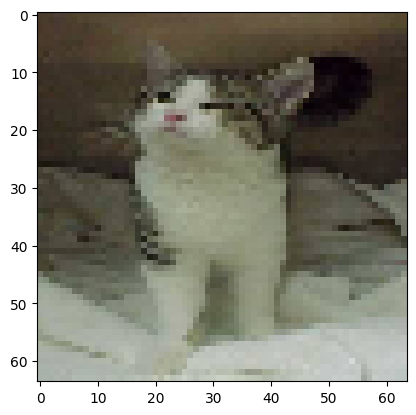

In [29]:
# Exemplo de classificação de uma imagem.
index = 21
plt.imshow(np.reshape(x_test_norm[index], (64, 64, 3)))
print ("classe real =" , y_test[index], ", imagem é prevista como sendo =", cl_prev[index])

**Interpretação dos resultados:**

O custo decrescendo durante o treinamento mostra que os parâmetros estão sendo ajustados de forma a que a rede está aprendendo os dados de treinamento. Como o custo obtido não é muito baixo, então, provavelmente é possível treinar ainda mais a rede para obter melhores resultados nos dados de treinamento.

Tente refazer as etapas 4.2, 4.3 e 4.4, aumentando o número de épocas para algo em torno de 5000, para retreinar a rede. Você verá que o custo de treinamento diminui até praticamente zero e a exatidão aumenta para quase 100%.

**Importante:** só tente treinar com mais épocas após entregar o seu trabalho, pois os resultados esperados são para o treinamento com 1000 épocas.

Contudo, nem sempre é bom treinar a rede até se obter custo perto de zero e exatidão 100% para os dados de treinamento. Em geral quando isso acontece o custo e a exatidão para os dados de teste pioraram. Nesse caso, pode ocorrer que a rede está memorizando os dados de treinamento e não generalizando a solução do problema. Veremos daqui algumas aulas como resolver esse problema. Mas podemos verificar esse fato retreinando a rede para um número maior de épocas.

## 5 - Desenvolvimento e teste da rede neural deep-learning ##

Nessa etapa do trabalho você vai configurar, treinar e testar uma rede neural deep learning.

**Qualquer dúvida que você possa ter de como fazer essa parte do trabalho, ela pode ser sanada olhando as notas da Aula 7 - Ferramentas de Desenvolvmento.**

### Exercício #10:

Usando o Keras configure e crie uma rede neural com as seguintes caracteríticas:

- três camadas intermediárias com função de ativação tipo ReLu;
- número de neurônios das camadas intermediárias: 64, 32, 16;
- camada de saída deve possuir um único neurônio e ter função de ativação sigmóide.

Essa rede deve ser criada dentro de uma função (build_model) e os argumentos dessa função são: a dimensão dos dados de entrada e os números de neurônios das diversas camadas.

In [31]:
# PARA VOCÊ FAZER: configuração da rede deep-learning

# Importar do Keras modelos e camadas
from tensorflow.keras import models
from tensorflow.keras import layers

def build_model(data_shape,n1,n2,n3,n4):
    """
    Essa função configura uma rede neural deep-learnig

    Argumentos:
    data_shape = tuple com dimensões dos dados de entrada da rede
    n1 = número de neurônios da primeira camada
    n2 = número de neurônios da segunda camada
    n3 = número de neurônios da terceira camada
    n4 = número de neurônios da camada de saída

    Retorna: modelo da rede neural
    """

    np.random.seed(3)

    model = models.Sequential()

    # Adicione as camadas em seu modelo de RNA
    #### COMECE AQUI ### (≈ 4 linhas)
    model.add(layers.Dense(n1, activation='relu', input_shape=data_shape))
    model.add(layers.Dense(n2, activation='relu'))
    model.add(layers.Dense(n3, activation='relu'))
    model.add(layers.Dense(n4, activation='sigmoid'))
    ### TERMINE AQUI ###

    return model

# Redefine semente para geração de números aleatórios
np.random.seed(3)

# Dimensão dos dados de entrada
#### COMECE AQUI ### (1 linha)
data_shape = (x_train_norm.shape[1],)
### TERMINE AQUI ###

# Definição dos números de neurônios das camadas
#### COMECE AQUI ### (≈ 4 linhas)
n1 = 64
n2 = 32
n3 = 16
n4 = 1
### TERMINE AQUI ###

# Cria rede neural deep learning e mostra sumário
#### COMECE AQUI ### (≈ 2 linhas)
rnadl = build_model(data_shape, n1, n2, n3, n4)
rnadl.summary()

### TERMINE AQUI ###

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │       786,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,121 (3.01 MB)

 Trainable params: 789,121 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

**Saída esperada:**

    Model: "sequential_1"
    _________________________________________________________________
    Layer (type)                 Output Shape              Param #   
    =================================================================
    dense_2 (Dense)              (None, 64)                786496    
    _________________________________________________________________
    dense_3 (Dense)              (None, 32)                2080      
    _________________________________________________________________
    dense_4 (Dense)              (None, 16)                528       
    _________________________________________________________________
    dense_5 (Dense)              (None, 1)                 17        
    =================================================================
    Total params: 789,121
    Trainable params: 789,121
    Non-trainable params: 0
    _________________________________________________________________

### Exercício #11:

Repita os itens 4.2, 4.3 e 4.4 para a rede neural deep-learning. Use `rnadl` como nome da rede e acrescentando as letras `dl` nas variáveis de custo, exatidao e epocas.

Na célula abaixo compile e treine a sua rede deep-learning para 10 épocas. Esse treinamento é só para verificar se o programa está correto.

In [33]:
# PARA VOCÊ FAZER: compilação e treinamento da rede deep-learning

# Compilação da rede
### COMECE AQUI ### (≈ 2 linhas)
rnadl.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
### TERMINE AQUI ###

# Teste de treinamento da rede
### COMECE AQUI ### (≈ 1 linha)
historydl = rnadl.fit(x_train_norm, y_train, epochs=10, batch_size=32, validation_data=(x_test_norm, y_test))
### TERMINE AQUI ###

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7560 - loss: 0.4763 - val_accuracy: 0.6238 - val_loss: 0.7063
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7498 - loss: 0.4783 - val_accuracy: 0.6258 - val_loss: 0.7965
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7696 - loss: 0.4614 - val_accuracy: 0.6233 - val_loss: 0.8137
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7813 - loss: 0.4474 - val_accuracy: 0.6134 - val_loss: 0.8438
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7762 - loss: 0.4469 - val_accuracy: 0.5922 - val_loss: 0.8251
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7660 - loss: 0.4587 - val_accuracy: 0.6105 - val_loss: 0.7995
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7747 - loss: 0.4544 - val_accuracy: 0.6327 - val_loss: 0.8316
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7903 - loss: 0.4302 - val_accuracy: 0

**Saída esparada:**

    Epoch 1/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5332 - loss: 0.6903
    Epoch 2/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5502 - loss: 0.6850
    Epoch 3/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5780 - loss: 0.6772
    Epoch 4/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5878 - loss: 0.6709
    Epoch 5/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6012 - loss: 0.6643
    Epoch 6/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6073 - loss: 0.6593
    Epoch 7/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6168 - loss: 0.6535
    Epoch 8/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6228 - loss: 0.6504
    Epoch 9/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6230 - loss: 0.6448
    Epoch 10/10
    63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6375 - loss: 0.6403

Na célula abaixo treine a sua rede deep-learning por 1000 épocas. Use verbose = 0 e batch_size = 128.

In [35]:
# PARA VOCÊ FAZER: treinamento da rede deep-learning por 1000 épocas

### COMECE AQUI ### (≈ 1 linha)
historydl = rnadl.fit(x_train_norm, y_train,epochs=1000, verbose=0, batch_size=128)
### TERMINE AQUI ###

# Vamos verificar quais variáveis foram salvas no processo de treinamento
historydl_dict = historydl.history
historydl_dict.keys()

dict_keys(['accuracy', 'loss'])

### Exercício #12:

Na célula abaixo introduza os comandos para visualizar os resultados da sua rede deep-learning.

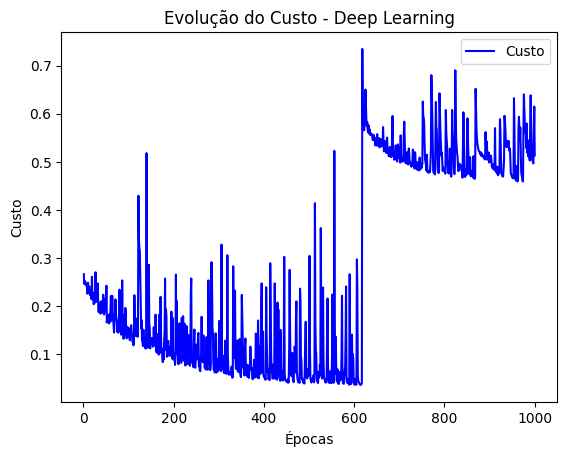

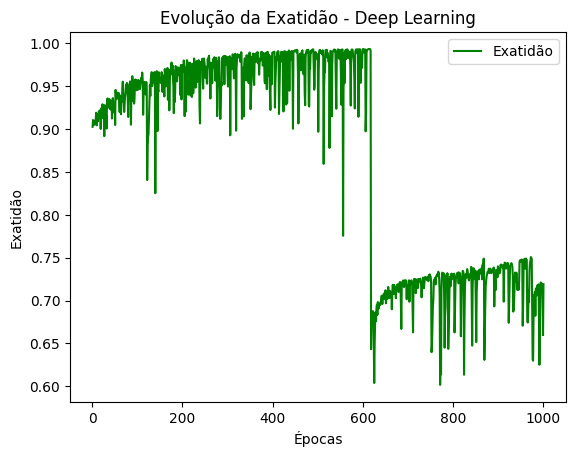

In [36]:
# PARA VOCÊ FAZER: visualização do resultado do treinamento da rede deep-learning

# Salva custo e exatidão em vetores
### COMECE AQUI ### (≈ 2 linhas)
custodl = historydl.history['loss']
exatidaodl = historydl.history['accuracy']
### TERMINE AQUI ###

# Cria vetor de épocas
### COMECE AQUI ### (≈ 1 linha)
epocasdl = range(1, len(custodl) + 1)
### TERMINE AQUI ###

# Gráfico do custo em funçaõ das épocas
### COMECE AQUI ### (≈ 6 linhas)
plt.plot(epocasdl, custodl, 'b-', label="Custo")
plt.title("Evolução do Custo - Deep Learning")
plt.xlabel("Épocas")
plt.ylabel("Custo")
plt.legend()
plt.show()
### TERMINE AQUI ###

# Gráfico da exatidão em função das épocas
### COMECE AQUI ### (≈ 6 linhas)
plt.plot(epocasdl, exatidaodl, 'g-', label="Exatidão")
plt.title("Evolução da Exatidão - Deep Learning")
plt.xlabel("Épocas")
plt.ylabel("Exatidão")
plt.legend()
plt.show()
### TERMINE AQUI ###

### Exercício #13:

Na célula abaixo introduza os comandos para avaliar a sua rede deep-learning para os dados de treinamento e de teste.

In [37]:
# PARA VOCÊ FAZER: calculo do custo e exatidão para os dados de treinamento e de teste para a rede deep-learning

# Usando método evaluate calcule o custo e a exatidão dos dados de treinamento e depois apresente os resultados
### COMECE AQUI ### (≈ 1 linha)
custo_e_metricasdl_train = rnadl.evaluate(x_train_norm, y_train)
### TERMINE AQUI ###
print(custo_e_metricasdl_train)

# Usando método evaluate calcule o custo e a exatidão dos dados de teste e depois apresente os resultados
### COMECE AQUI ### (≈ 1 linha)
custo_e_metricasdl_test = rnadl.evaluate(x_test_norm, y_test)
### TERMINE AQUI ###
print(custo_e_metricasdl_test)

251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7131 - loss: 0.5186
[0.5169809460639954, 0.7170518636703491]
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5495 - loss: 0.9321
[0.9231656789779663, 0.5486900806427002]


**Saída esperada:**

    251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 4.0687e-04
    [0.0004092703165952116, 1.0]
    64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6455 - loss: 2.8204
    [2.809940814971924, 0.6337122917175293

### Exercício #14:

Na célula abaixo introduza os comandos para clcular as classes previstas para os dados de teste.

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


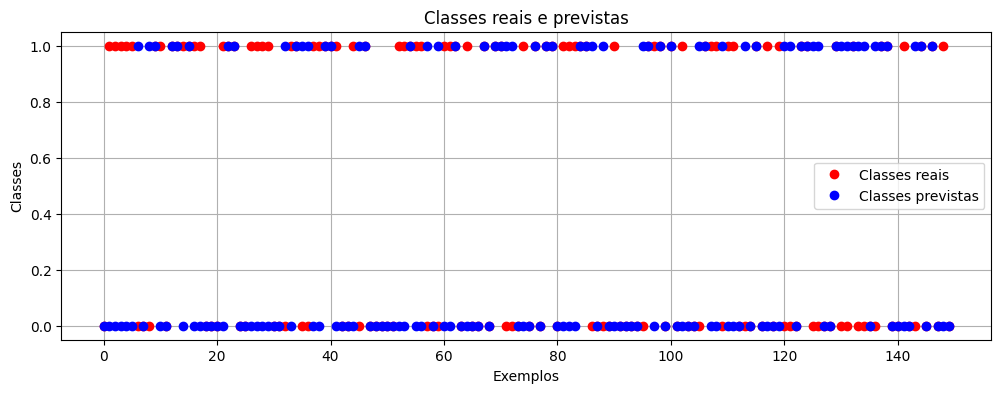

In [39]:
# PARA VOCÊ FAZER: calculo das classes previstas dos dados de teste para a rede deep-learning

# Usando método predict calcule as classes previstas
### COMECE AQUI ### (≈ 3 linhas)
y_preddl = rnadl.predict(x_test_norm)
cl_prevdl = (y_preddl > 0.5).astype(int).flatten()

# Transforma saida prevista em números inteiros

### TERMINE AQUI ###



# Gráfico das classes reais e previstas
### COMECE AQUI ### (≈ 7 linhas)
plt.figure(figsize=(12, 4))
plt.plot(y_test[:150], 'ro', label='Classes reais')
plt.plot(cl_prevdl[:150], 'bo', label='Classes previstas')
plt.title('Classes reais e previstas')
plt.xlabel('Exemplos')
plt.ylabel('Classes')
plt.legend()
plt.grid()
plt.show()
### TERMINE AQUI ###

**Saída esperada:**

O número de erros de classificação é de cerca de 50, representado por cerca de 50 bolinhas vermelhas, o que significa representa 1/3 dos exemplos de teste.

**Interpretação dos resultados:**

Se você fez tudo correto, então, os resultados obtidos do custo e da exatidão para os dados de teste são melhores para a rede neural deep-learning do que para a rede neural rasa, como era de se esperar.

Observe que a rede deep learning possui quase o mesmo número de parâmetros do que a rede rasa, mas obtém resultados mais satisfatórios.

O que fez com que os resultados da rede deep learning fossem muito melhores do que a rede rasa? O número de camadas, o tipo de função de ativação, ou simplesmenete o número de parâmetros?

<font color='blue'>
    
**O que é importante lembrar:**
- A escolha do número de neurônios das camadas da rede é muito importane
- O tipo de função de ativação usada pode fazer diferença nos resultados
- Não é uma tarefa fácil desenvolver uma rede neural que apresenta um desempenho bom, mas não é impossível

### Exercício #15:

Teste as redes que você desenvolveu com sua própria imagem. Você pode usar qualquer imagem e verificar se as suas redes neurais são eficientes.

Para fazer isso tem que primeiro carragar a imagem:

    1. Abra a janela direita co Colab e carregue a imagem desejada.
    2. Troque o nome do arquivo onde se encontra a imagem no código abaixo.
    3. Execute o código e verifique se a rede acerta (1 = imagem mostra gato, 0 = imagem não tem gato)!

Previsão do modelo: 1


Exception ignored in: <function _xla_gc_callback at 0x7d229002c2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


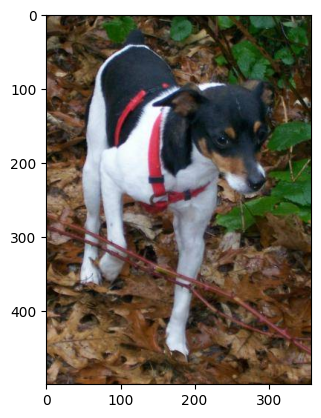

In [56]:
# PARA VOCÊ FAZER: teste da rede com suas imagens

## COMECE AQUI ## (coloque o nome do arquivo com a sua imagem)
my_image = "/content/GatoLogan.jpg"#" my_image.jpg" -troca nome para o nome do arquivo com a sua imagem
## TERMINE AQUI ##

# Pré-processamento da imagem para acertar dimensões.
fname = my_image
my_image = tf.keras.utils.load_img(fname)
my_image = tf.keras.utils.img_to_array(my_image)
my_image = tf.image.resize(my_image, [64,64]).numpy()
my_uimage = my_image/255.
my_image = my_image.reshape((1, num_px*num_px*3))
my_image = my_image.astype(float)

# Previsão da rede neural
y_prev_myimage = rnadl.predict(my_image, verbose=0)
my_predicted_image = np.round(y_prev_myimage)
my_predicted_image = my_predicted_image.astype(int)

plt.imshow(image)
print("Previsão do modelo:", np.squeeze(my_predicted_image))

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Finalmente, como sugestão, tente fazer alterações de parâmetros e executar o notebook novamente. Mas lembre-se de salvar o seu trabalho em um arquivo pdf e enviar para avaliação antes de modificar o notebook e realizar os seus testes.

Algumas sugestões do que alterar:

- Número de camadas;
- Número de neurônios nas camadas;
- Funções de ativação;
- Tente impor um taxa de aprendizado;
- Tente outras formas de normalizar os dados.
